PLOT OF AVAILABLE OTHER GASES observed at MKN

O3, CO, H2, Ethane, Other VOCs (2-Methylbutane, 2-Methylpropane, n-Butane, n-Pentane, Propane)
event and daily resolution where possible
H2  (& CO) data obtained from WDCGG: https://gaw.kishou.go.jp/ (login: used Jörg's account) - September 2023
O3, CO, VOCs data obtained from EBAS: https://ebas-data.nilu.no/Default.aspx - September 2023
newest O3 data obtained from MCH

Author: Sarina Danioth (formerly MeteoSwiss)
Maintainer: joerg.klausen@meteoswiss.ch

[TODO] Needs further clean-up and integration. Not all data sources are currently available from this repo.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import nappy
from datetime import datetime
import itertools

from processing import ebas

In [6]:
#### O3 DATA (EBAS) ####
# read O3 data files and put into data frame
ebas_data = os.getcwd()+"/data/wdc/ebas/air/"
data_O3_all = ebas.compile_ebas_ozone_data_into_dataframe(data_path=ebas_data)
data_O3_all.describe()

,starttime,endtime,O3_0,O3_1,flag,dtm,O3_2,O3_3
count,148992.000000,148992.000000,79975.000000,79975.000000,148992.000000,148992,62117.000000,62117.000000
mean,182.569192,182.610859,32.508079,26.594215,0.462763,2016-02-16 03:59:31.005154816,2.378240,1.191894
min,0.000000,0.041667,0.601401,2.500000,0.000000,2002-06-01 00:00:00,0.319000,0.160000
25%,91.291667,91.333333,27.300109,19.550000,0.000000,2015-04-02 00:00:00,1.417000,0.710000
50%,182.583333,182.625000,32.690168,30.850000,0.000000,2019-03-03 00:00:00,1.995000,1.000000
75%,273.875000,273.916667,37.430212,36.460000,0.999000,2020-11-16 00:00:00,2.873000,1.440000
max,365.958333,366.000000,77.679994,77.680000,0.999000,2024-01-01 00:00:00,27.256000,13.660000
std,105.419360,105.419360,8.053387,14.350756,0.498149,NaN,1.527061,0.765313


In [32]:
#### O3 DATA (MeteoSwiss) - year 2022 & 2023 (until October) ####

# path = os.getcwd()+"/data/ozone_MCH"

# data_O3_mch = pd.DataFrame()

# for file in os.listdir(path):
#     if "ozone" in str(file):
#         data_O3_mch = pd.concat([data_O3_mch, pd.read_csv(path+"/"+file, low_memory=False)])

# data_O3_mch['timestamp'] = data_O3_mch["pcdate"] + " " + data_O3_mch["pctime"]
# data_O3_mch['timestamp'] = pd.to_datetime(data_O3_mch['timestamp'])
# data_O3_mch['timestamp']
# data_O3_mch_hourly = pd.DataFrame()
# data_O3_mch_hourly[["o3"]] = data_O3_mch.groupby(data_O3_mch['timestamp'].dt.strftime("%y-%m-%d %H"))[["o3"]].mean(numeric_only=True)
# data_O3_mch_hourly.index.name = 'timestamp'
# data_O3_mch_hourly.reset_index(inplace=True)
# data_O3_mch_hourly['timestamp'] = pd.to_datetime(data_O3_mch_hourly['timestamp'], format="%y-%m-%d %H")


In [7]:
#### CO DATA (EBAS) ####

# read CO data files and put into data frame
data_CO_all = pd.DataFrame()

for file in os.listdir(ebas_data):
    if "carbon_monoxide" in str(file):
        ebas_data_CO = ebas_data + file
        fh = nappy.openNAFile(ebas_data_CO)
        fh.readData()
        X = fh.X
        V = fh.V
        na_values = fh.VMISS
        for row in range(len(na_values)):
            V[row] = [None if x == na_values[row] else x for x in V[row]]
        X = pd.DataFrame(X)
        X.columns = fh.XNAME
        V = pd.DataFrame(V).T
        V.columns = fh.VNAME
        df_CO = X.merge(V, left_index=True, right_index=True)
        long_names = ebas.list2df(list(df_CO.columns))
        long_names.rename(columns={0: 'long_name', 1: "unit"}, inplace=True)
        df_CO.columns = fh.getNADict()['NCOM'][-1].split()
        inc = itertools.count().__next__
        dups = df_CO.columns[df_CO.columns.duplicated()]
        df_CO.rename(columns=lambda x: f"{x}_{inc()}" if x in dups else x, inplace=True)
        short_names = pd.DataFrame(df_CO.columns)
        short_names.rename(columns={0: 'short_name'}, inplace=True)
        mappings = pd.concat([short_names, long_names], axis=1)
        epoch = datetime.strptime("%s-%s-%s" % tuple(fh.DATE), "%Y-%m-%d")
        df_CO['dtm'] = epoch + pd.to_timedelta(round(df_CO['starttime']), unit='D')
        df_CO.set_index('dtm')

        data_CO_all = pd.concat([data_CO_all, df_CO])

In [8]:
#### VOCs (EBAS) ####


data_path = ebas_data+"/KE0001G.20060224084500.20210831185838.glass_flask..air.5y.12d.US13L_glass_flask_KE0001G.US13L_GC_FID_v1.lev2.nas"

fh = nappy.openNAFile(data_path)
fh.readData()

X = fh.X
V = fh.V
na_values = fh.VMISS
for row in range(len(na_values)):
    V[row] = [None if x == na_values[row] else x for x in V[row]]

X = pd.DataFrame(X)
X.columns = fh.XNAME
V = pd.DataFrame(V).T
V.columns = fh.VNAME

df_air = X.merge(V, left_index=True, right_index=True)
long_names = ebas.list2df(list(df_air.columns))
long_names.rename(columns={0: 'long_name', 1: "unit"}, inplace=True)
df_air.columns = fh.getNADict()['NCOM'][-1].split()
inc = itertools.count().__next__
dups = df_air.columns[df_air.columns.duplicated()]
df_air.rename(columns=lambda x: f"{x}_{inc()}" if x in dups else x, inplace=True)
short_names = pd.DataFrame(df_air.columns)
short_names.rename(columns={0: 'short_name'}, inplace=True)
mappings = pd.concat([short_names, long_names], axis=1)
epoch = datetime.strptime("%s-%s-%s" % tuple(fh.DATE), "%Y-%m-%d")
df_air['dtm'] = epoch + pd.to_timedelta(round(df_air['starttime']), unit='D')
df_air.set_index('dtm')

,starttime,endtime,C5H12_0,flag_C5H12_1,C5H12_2,flag_C5H12_3,C5H12_4,flag_C5H12_5,C5H12_6,flag_C5H12_7,...,C5H12_38,flag_C5H12_39,C5H12_40,flag_C5H12_41,C3H8_42,flag_C3H8_43,C3H8_44,flag_C3H8_45,C3H8_46,flag_C3H8_47
dtm,,,,,,,,,,,,,,,,,,,,,
2006-02-24,54.364583,54.365278,15.248,0.0,49.08,0.0,2.0,0.0,5.542,0.000,...,4.962,0.000,15.97,0.000,97.043,0.0,2.0,0.0,25.760,0.0
2006-03-08,66.368056,66.368750,19.897,0.0,64.05,0.0,2.0,0.0,4.185,0.000,...,0.000,0.000,0.00,0.000,75.541,0.0,2.0,0.0,7.501,0.0
2006-03-20,78.375000,78.375694,25.159,0.0,80.99,0.0,2.0,0.0,3.747,0.000,...,2.947,0.000,9.49,0.000,113.592,0.0,2.0,0.0,21.452,0.0
2006-03-28,86.481250,86.481944,24.154,0.0,77.75,0.0,1.0,0.0,NaN,0.899,...,NaN,0.899,NaN,0.899,50.884,0.0,2.0,0.0,5.339,0.0
2006-04-04,93.348611,93.349306,20.792,0.0,66.93,0.0,2.0,0.0,5.074,0.000,...,6.215,0.000,20.01,0.000,48.700,0.0,2.0,0.0,1.125,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-05-06,1951.403472,1951.404167,1085.648,0.0,3494.72,0.0,2.0,0.0,115.304,0.000,...,66.921,0.000,215.42,0.000,98.510,0.0,2.0,0.0,9.179,0.0
2011-05-13,1957.524259,1957.524954,52.765,0.0,169.85,0.0,2.0,0.0,1.478,0.000,...,0.240,0.000,0.77,0.000,53.433,0.0,2.0,0.0,2.238,0.0
2011-05-28,1973.354167,1973.354861,51.925,0.0,167.15,0.0,2.0,0.0,3.009,0.000,...,5.204,0.000,16.75,0.000,68.000,0.0,2.0,0.0,7.362,0.0


In [10]:
#### H2 & CO (WDCGG) ####

gases = ["CO", "H2"]
df = {} # dictionary to save data frames

for g in gases:

    path = os.getcwd()+"/data/wdc/wdcgg/"+g+"/"
    files = os.listdir(path)

    for file in files:
        # Flask (event) 
        if "event" in file:
            event_file = os.path.join(path, file)

            #open file
            with open(event_file) as f:
                while line := f.readline():
                    if line.strip() == "# VARIABLE ORDER":
                        break
                event_data = pd.read_csv(f, sep=" ", skiprows=2, na_values=['-999', '-9', '-99.9', '-999.999'], header=None)
                event_data.index += 1

            event_data.columns = ["site_gaw_id", "year", "month", "day", "hour", "minute", "second", "year1", "month1", "day1", "hour1", "minute1", "second1", "value", "value_unc", "nvalue", "latitude", "longitude", "altitude", "elevation", "intake_height", "flask_no", "ORG_QCflag", "QCflag", "instrument", "measurement_method", "scale"]
            event_df = pd.DataFrame(event_data)
            # create date column out of year, month and day column
            date = (pd.to_datetime(event_df[['year', 'month', 'day']]))
            event_df["date"] = date
            # name event df and save in dictionary
            df_name = g + "_event"
            df[df_name] = event_df

        # Continuous (daily aggregates)
        if "daily" in file:
            daily_file = os.path.join(path, file)
            
            # open file
            with open(daily_file) as f:
                while line := f.readline():
                    if line.strip() == "# VARIABLE ORDER":
                        break
                daily_data = pd.read_csv(f, sep=" ", skiprows=2, na_values=['-999', '-9', '-99.9', '-999.999'], header=None)
                daily_data.index += 1

            daily_data.columns = ["site_gaw_id", "year", "month", "day", "hour", "minute", "second", "year1", "month1", "day1", "hour1", "minute1", "second1", "value", "value_unc", "nvalue", "latitude", "longitude", "altitude", "elevation", "intake_height", "flask_no", "ORG_QCflag", "QCflag", "instrument", "measurement_method", "scale"]
            daily_df = pd.DataFrame(daily_data)
            # create date column out of year, month and day column
            date = (pd.to_datetime(daily_df[['year', 'month', 'day']]))
            daily_df["date"] = date
            # name daily df and save in dictionary
            df_name = g + "_daily"
            df[df_name] = daily_df

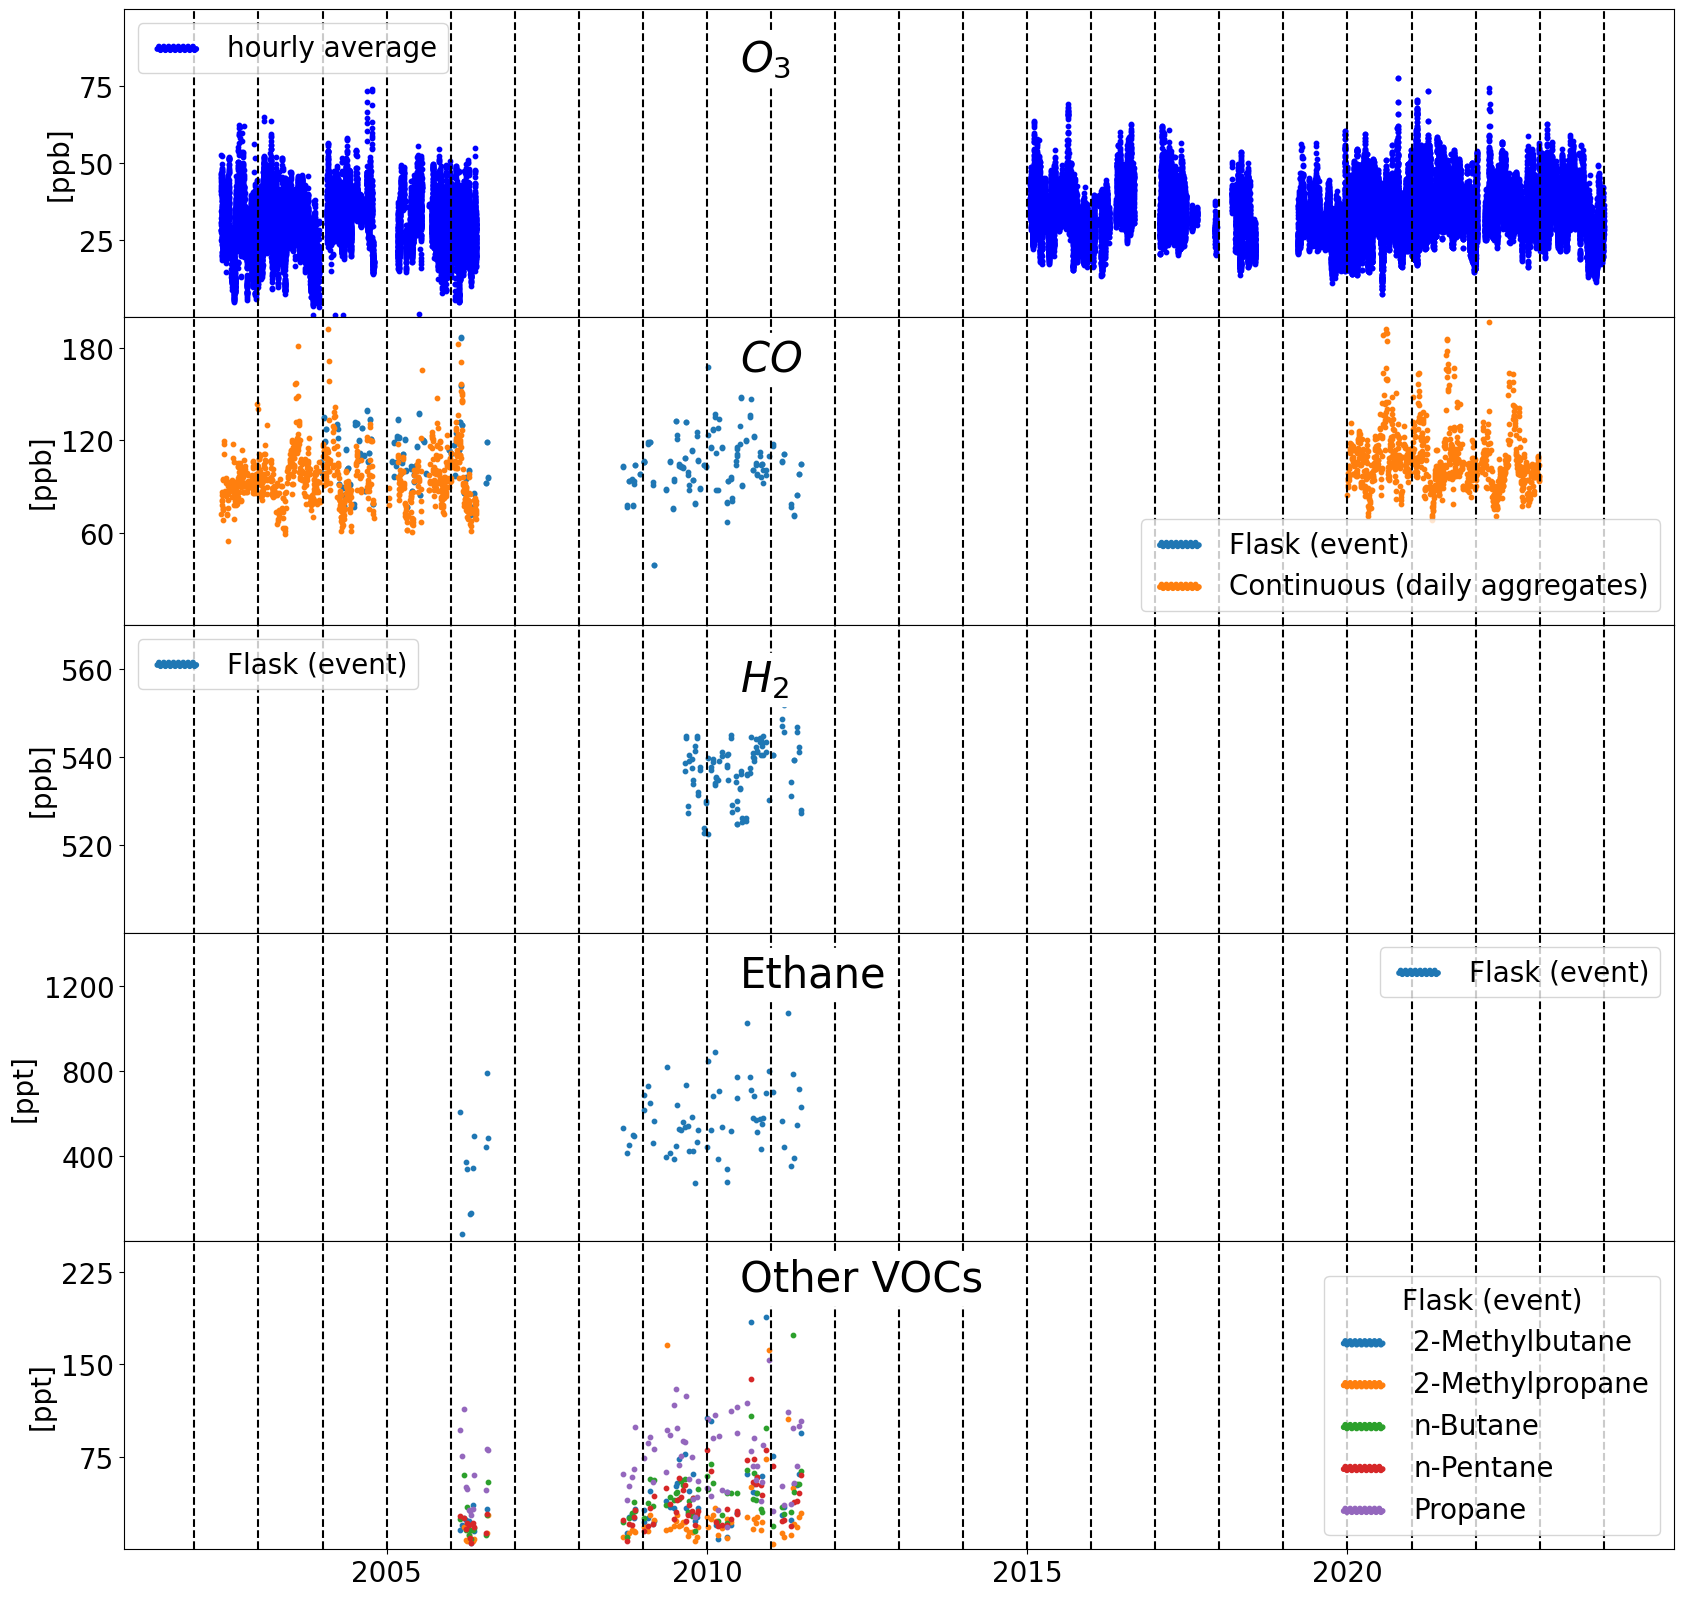

In [12]:
# Make Plot

fig = plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0)
ax1 = plt.subplot(511)
ax2 = plt.subplot(512)
ax3 = plt.subplot(513)
ax4 = plt.subplot(514)
ax5 = plt.subplot(515)

# xlabel
x_dates = []
for y in range(2002,2025):
    x_dates.append(str(y)+"-01-01")

#### O3 ####
ax1.scatter(data_O3_all["dtm"],data_O3_all["O3_0"], marker="o", s= 10, c="blue", label="hourly average") 
# ax1.scatter(data_O3_mch_hourly["timestamp"],data_O3_mch_hourly["o3"], marker="o", s= 10, c="blue") 
ax1.legend(loc="upper left", fontsize=20, scatterpoints=25)
ax1.set_ylim(0,100)
ax1.set_ylabel("[ppb]", fontsize=20)
ax1.vlines(x = x_dates, ymin=0, ymax=200, colors="k", ls="--")
ax1.set_yticks([25,50, 75])
t = ax1.text(14800, 80, "$O_3$", fontsize=30, fontweight="semibold")
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax1.tick_params(axis="y", labelsize=20)

#### CO ####
# ax2.scatter(data_CO_all["dtm"],data_CO_all["CO_0"], marker="o", s= 10, c="blue", label="WDCGG") # data from EBAS
ax2.scatter(df["CO_event"]["date"], df["CO_event"]["value"], marker="o", s= 10, label="Flask (event)") # data from WDCGG
ax2.scatter(df["CO_daily"]["date"], df["CO_daily"]["value"], marker="o", s= 10, label="Continuous (daily aggregates)") # data from WDCGG
ax2.legend(loc="lower right", fontsize=20, scatterpoints=25)
ax2.set_ylim(0,200)
ax2.set_ylabel("[ppb]", fontsize=20)
ax2.vlines(x = x_dates, ymin=0, ymax=1500, colors="k", ls="--")
ax2.set_yticks([60,120, 180])
t = ax2.text(14800, 165, "$CO$", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax2.tick_params(axis="y", labelsize=20)

#### H2 ####
ax3.scatter(df["H2_event"]["date"], df["H2_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax3.legend(loc="upper left", fontsize=20, scatterpoints=25)
ax3.set_ylim(500,570)
ax3.set_ylabel("[ppb]", fontsize=20)
ax3.vlines(x = x_dates, ymin=0, ymax=580, colors="k", ls="--")
ax3.set_yticks([520,540,560])
t = ax3.text(14800, 555, "$H_2$", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax3.tick_params(axis="y", labelsize=20)

#### Ethane ####
ax4.scatter(df_air["dtm"][df_air["flag_C2H6_17"] == 0.00],df_air["C2H6_16"][df_air["flag_C2H6_17"] == 0.00], marker="o", s= 10, label="Flask (event)")
ax4.legend(loc="upper right", fontsize=20, scatterpoints=25)
ax4.set_ylim(0,1450)
ax4.set_ylabel("[ppt]", fontsize=20)
ax4.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax4.set_yticks([400,800, 1200])
t = ax4.text(14800, 1200, "Ethane", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax4.tick_params(axis="y", labelsize=20)

#### Other VOCs ####
ax5.scatter(df_air["dtm"][df_air["flag_C5H12_1"] == 0.00],df_air["C5H12_0"][df_air["flag_C5H12_1"] == 0.00], marker="o", s= 10, label="2-Methylbutane")
ax5.scatter(df_air["dtm"][df_air["flag_C4H10_11"] == 0.00],df_air["C4H10_10"][df_air["flag_C4H10_11"] == 0.00], marker="o", s= 10, label="2-Methylpropane")
ax5.scatter(df_air["dtm"][df_air["flag_C4H10_23"] == 0.00],df_air["C4H10_22"][df_air["flag_C4H10_23"] == 0.00], marker="o", s= 10,  label="n-Butane")
ax5.scatter(df_air["dtm"][df_air["flag_C5H12_33"] == 0.00],df_air["C5H12_32"][df_air["flag_C5H12_33"] == 0.00], marker="o", s= 10,  label="n-Pentane")
ax5.scatter(df_air["dtm"][df_air["flag_C3H8_43"] == 0.00],df_air["C3H8_42"][df_air["flag_C3H8_43"] == 0.00], marker="o", s= 10,  label="Propane")
ax5.set_ylim(0,250)
ax5.set_ylabel("[ppt]", fontsize=20)
ax5.vlines(x = x_dates, ymin=0, ymax=4200, colors="k", ls="--")
ax5.set_yticks([75,150, 225])
t = ax5.text(14800, 210, "Other VOCs", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax5.tick_params(axis="y", labelsize=20)
ax5.tick_params(axis="x", labelsize=20)
ax5.legend(loc="lower right", fontsize=20, scatterpoints=25, title="Flask (event)", title_fontsize=20)
ax5.set_xticks(["2005","2010", "2015", "2020"], ["2005","2010", "2015", "2020"])
ax5.tick_params(axis="x", labelsize=20)


# save figure
fig.savefig(os.getcwd()+"/results/plots/Other_gases.jpeg", bbox_inches='tight')